In [6]:
from brian2 import *
import matplotlib.pyplot as plt
from plottingTools import *

In [ ]:
#Code used by Federica to generate her input
class Gaussian_Input_Generator:
    def __init__(self,
                 n,
                 m=0,
                 mu=0,
                 sigma=1,
                 noise=False,
                 normalised=True
                 verbose=False):
        
        self.n=n
        self.m=m  #amplitude
        self.mu=mu #peak position (preferred direction of the corresponding neuron (theta in gradi))
        self.sigma=sigma #refers to the certainty of the cue
        self.noise=noise
        self.normalised=normalised
        self.x=np.linspace(0, 360, self.n, endpoint=True)
        self.y=None        
    
    def generate_cue(self):
    
        # Create a wrap based on the number of neurons
        wraps = np.arange(-self.n/2, self.n/2+1)
        gaussianComponent = np.exp(-0.5 * ((self.x[:,np.newaxis]-self.mu+wraps*360) /self.sigma)**2)
        wrappedGaussian = self.m * np.sum(gaussianComponent, axis=1)
        normalizationTerm=1/(self.sigma*((2*pi)**0.5))

        y=wrappedGaussian
        
        if self.noise:
            y=self.add_noise(y)
            
        if self.normalised:
            y=y*normalizationTerm
        
        if self.verbose:
            for index, (angle, value) in enumerate(zip(self.x, y)):
                print('Gaussian', index, 'at', angle, 'has value', value)
            
            print('The angle should theoretically be', self.mu,
                '.\nThe peak is at', self.x[np.argmax(y)],
                '. The respective neuron is', np.argmax(y))
        self.y = y
        return y
    
    
    def plot_gaussians_polar(self):
        # Generate the wrapped Gaussian values
        gaussian_values = self.generate_cue()
        
        plot_on_circle(self.x, gaussian_values, title='Wrapped Gaussian on a Circle',
                       legend_label='Wrapped Gaussian', legend_kwargs={'loc': 'upper right'})


    def add_noise(self,I):
        I_noisy=I+normal(0,1,len(self.x))*2e-2
        return I_noisy
    
    def to_brian2_neuron_group(self):
        input_gen = NeuronGroup(self.n, 'I : 1', threshold='I > 0', reset='I = 0', method='exact')
        if self.y is None:
            input_gen.I = self.generate_cue()
        else:
            input_gen.I = self.y
        return input_gen

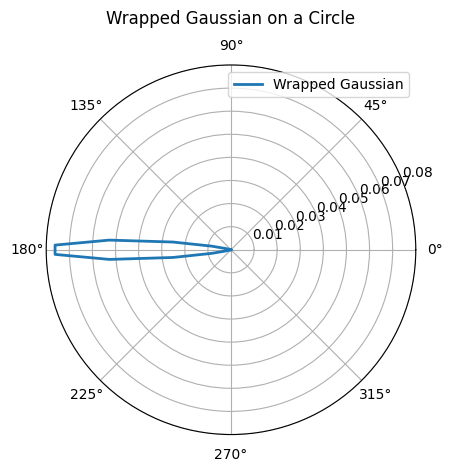

In [8]:
num_neurons = 120
duration = 100*ms

gaussian_gen = Gaussian_Input_Generator(num_neurons, m=1, mu=180, sigma=5, noise=False, normalised=True)
gaussian_gen.plot_gaussians_polar()

In [9]:
input_gen = gaussian_gen.to_brian2_neuron_group()
spike_monitor_input = SpikeMonitor(input_gen, name="spike_input")
run(duration)

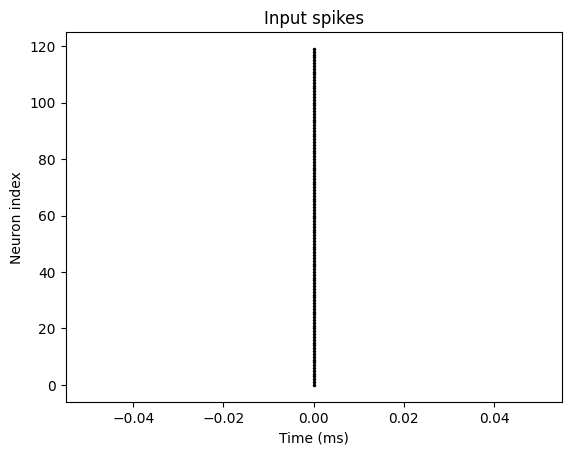

In [10]:
# plotting
plt.figure()
plt.plot(spike_monitor_input.t/ms, spike_monitor_input.i, '.k', ms=3)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Input spikes')
plt.show()
